In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score
from scipy.stats import randint, uniform
import time
from sklearn.pipeline import Pipeline

In [2]:
# Set random seed for reproducibility
np.random.seed(42)

In [3]:
# Load a classification dataset
cancer = load_breast_cancer()
X_class = cancer.data
y_class = cancer.target

In [4]:
# Load a regression dataset
diabetes = load_diabetes()
X_reg = diabetes.data
y_reg = diabetes.target

In [5]:
# Split data into training and testing sets
X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

In [6]:
# Standardize features
scaler = StandardScaler()
X_class_train_scaled = scaler.fit_transform(X_class_train)
X_class_test_scaled = scaler.transform(X_class_test)

In [7]:
X_reg_train_scaled = scaler.fit_transform(X_reg_train)
X_reg_test_scaled = scaler.transform(X_reg_test)

# Part 1: Grid Search for SVM Classifier

In [8]:
# Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'poly']
}

In [9]:
# Create SVM classifier
svm = SVC(random_state=42)

In [10]:
# Create GridSearchCV object
grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=0,
    scoring='accuracy',
    return_train_score=True
)

In [11]:
# Start timing
start_time = time.time()


In [12]:
# Fit GridSearchCV
grid_search.fit(X_class_train_scaled, y_class_train)

GridSearchCV(cv=5, estimator=SVC(random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1],
                         'kernel': ['rbf', 'poly']},
             return_train_score=True, scoring='accuracy')

In [13]:
# End timing
grid_time = time.time() - start_time

In [14]:
# Print results
print(f"Grid Search completed in {grid_time:.2f} seconds")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

Grid Search completed in 8.20 seconds
Best parameters: {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
Best cross-validation score: 0.9736


In [15]:
# Evaluate on test set
y_pred = grid_search.predict(X_class_test_scaled)
grid_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {grid_accuracy:.4f}")

Test accuracy with optimal parameters: 0.9825


In [16]:
# Visualization of Grid Search results
grid_results = pd.DataFrame(grid_search.cv_results_)
grid_pivot = grid_results.pivot_table(
    values='mean_test_score',
    index='param_C',
    columns='param_gamma'
)

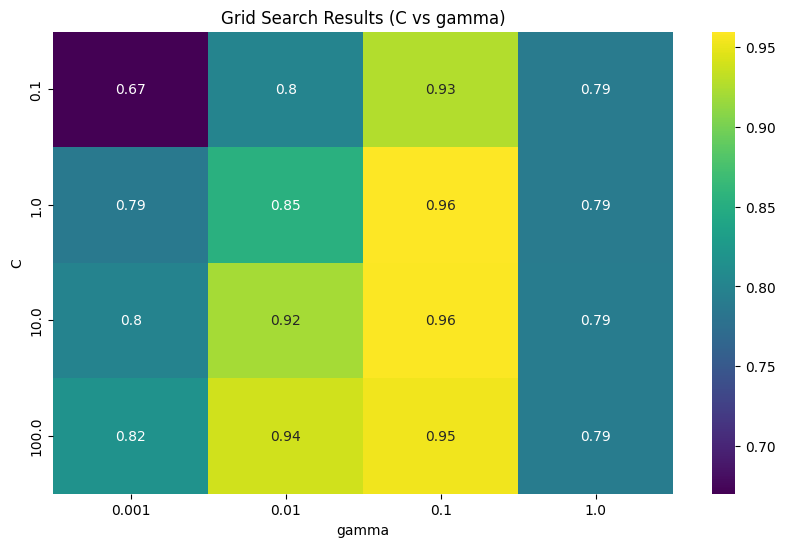

In [17]:
plt.figure(figsize=(10, 6))
sns.heatmap(grid_pivot, annot=True, cmap='viridis')
plt.title('Grid Search Results (C vs gamma)')
plt.ylabel('C')
plt.xlabel('gamma')
plt.show()


# Part 2: Random Search for SVM Classifier

In [18]:
# Define the parameter distributions
param_dist = {
    'C': uniform(0.1, 100),
    'gamma': uniform(0.001, 1),
    'kernel': ['rbf', 'poly']
}


In [19]:
# Create RandomizedSearchCV object
random_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=param_dist,
    n_iter=20,  # Number of parameter settings sampled
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='accuracy',
    return_train_score=True
)

In [20]:
# Start timing
start_time = time.time()

In [21]:
# Fit RandomizedSearchCV
random_search.fit(X_class_train_scaled, y_class_train)

RandomizedSearchCV(cv=5, estimator=SVC(random_state=42), n_iter=20, n_jobs=-1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7de527689940>,
                                        'gamma': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7de527b7a270>,
                                        'kernel': ['rbf', 'poly']},
                   random_state=42, return_train_score=True,
                   scoring='accuracy')

In [22]:
# End timing
random_time = time.time() - start_time

In [23]:
# Print results
print(f"Random Search completed in {random_time:.2f} seconds")
print(f"Best parameters: {random_search.best_params_}")
print(f"Best cross-validation score: {random_search.best_score_:.4f}")

Random Search completed in 2.05 seconds
Best parameters: {'C': np.float64(0.8066305219717406), 'gamma': np.float64(0.024062425041415758), 'kernel': 'rbf'}
Best cross-validation score: 0.9714


In [24]:
# Evaluate on test set
y_pred = random_search.predict(X_class_test_scaled)
random_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {random_accuracy:.4f}")

Test accuracy with optimal parameters: 0.9649


In [25]:
# Compare Grid Search and Random Search
results_comparison = pd.DataFrame({
    'Method': ['Grid Search', 'Random Search'],
    'Best CV Score': [grid_search.best_score_, random_search.best_score_],
    'Test Accuracy': [grid_accuracy, random_accuracy],
    'Execution Time (s)': [grid_time, random_time]
})

print("\nComparison of Grid Search and Random Search:")
print(results_comparison)


Comparison of Grid Search and Random Search:
          Method  Best CV Score  Test Accuracy  Execution Time (s)
0    Grid Search       0.973626       0.982456            8.203218
1  Random Search       0.971429       0.964912            2.053480


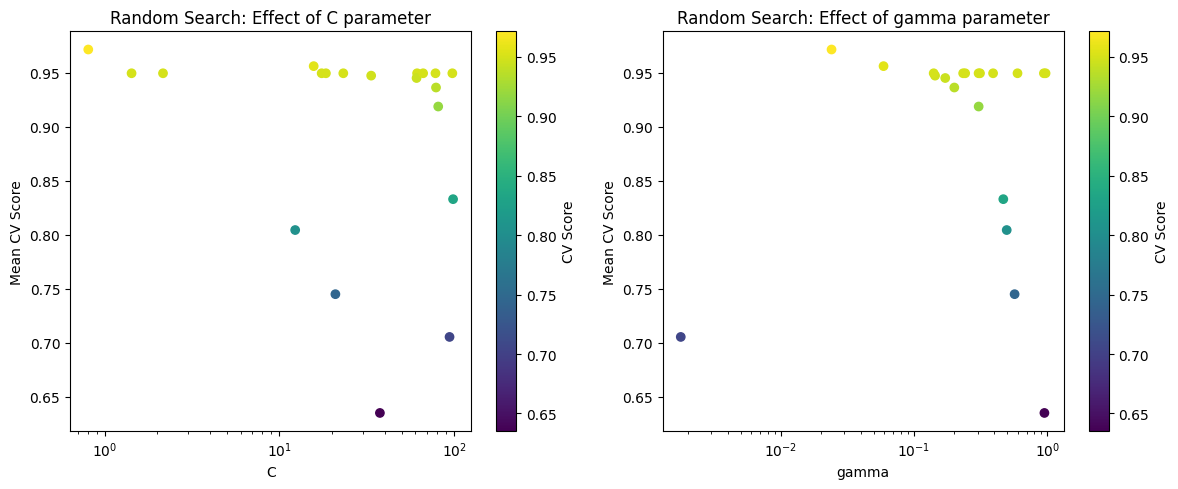

In [26]:
# Visualize random search results - plot parameter samples and their scores
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(random_search.cv_results_['param_C'],
            random_search.cv_results_['mean_test_score'],
            c=random_search.cv_results_['mean_test_score'],
            cmap='viridis')
plt.colorbar(label='CV Score')
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('Mean CV Score')
plt.title('Random Search: Effect of C parameter')

plt.subplot(1, 2, 2)
plt.scatter(random_search.cv_results_['param_gamma'],
            random_search.cv_results_['mean_test_score'],
            c=random_search.cv_results_['mean_test_score'],
            cmap='viridis')
plt.colorbar(label='CV Score')
plt.xscale('log')
plt.xlabel('gamma')
plt.ylabel('Mean CV Score')
plt.title('Random Search: Effect of gamma parameter')
plt.tight_layout()
plt.show()

# Part 3: Bayesian Optimization using scikit-optimize (skopt)

In [27]:
# Install scikit-optimize if not already installed
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 8.4 MB/s eta 0:00:00


In [28]:
!pip install skopt

ERROR: Could not find a version that satisfies the requirement skopt (from versions: none)
ERROR: No matching distribution found for skopt


In [29]:
import skopt
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

In [30]:
# Define the search space
search_spaces = {
    'C': Real(0.1, 100, prior='log-uniform'),
    'gamma': Real(0.001, 1.0, prior='log-uniform'),
    'kernel': Categorical(['rbf', 'poly'])
}

In [31]:
# Create BayesSearchCV object
bayes_search = BayesSearchCV(
    estimator=svm,
    search_spaces=search_spaces,
    n_iter=20,  # Number of parameter settings sampled
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='accuracy',
    return_train_score=True
)

In [32]:
# Start timing
start_time = time.time()

In [33]:
# Fit BayesSearchCV
bayes_search.fit(X_class_train_scaled, y_class_train)

BayesSearchCV(cv=5, estimator=SVC(random_state=42), n_iter=20, n_jobs=-1,
              random_state=42, return_train_score=True, scoring='accuracy',
              search_spaces={'C': Real(low=0.1, high=100, prior='log-uniform', transform='normalize'),
                             'gamma': Real(low=0.001, high=1.0, prior='log-uniform', transform='normalize'),
                             'kernel': Categorical(categories=('rbf', 'poly'), prior=None)})

In [34]:
# End timing
bayes_time = time.time() - start_time

In [35]:
# Print results
print(f"Bayesian Optimization completed in {bayes_time:.2f} seconds")
print(f"Best parameters: {bayes_search.best_params_}")
print(f"Best cross-validation score: {bayes_search.best_score_:.4f}")

Bayesian Optimization completed in 32.35 seconds
Best parameters: OrderedDict({'C': 47.479208101330435, 'gamma': 0.01504196942704713, 'kernel': 'rbf'})
Best cross-validation score: 0.9626


In [36]:
# Evaluate on test set
y_pred = bayes_search.predict(X_class_test_scaled)
bayes_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {bayes_accuracy:.4f}")

Test accuracy with optimal parameters: 0.9561


In [37]:
# Update comparison table
results_comparison = pd.DataFrame({
    'Method': ['Grid Search', 'Random Search', 'Bayesian Optimization'],
    'Best CV Score': [grid_search.best_score_, random_search.best_score_, bayes_search.best_score_],
    'Test Accuracy': [grid_accuracy, random_accuracy, bayes_accuracy],
    'Execution Time (s)': [grid_time, random_time, bayes_time]
})

print("\nComparison of all methods:")
print(results_comparison)


Comparison of all methods:
                  Method  Best CV Score  Test Accuracy  Execution Time (s)
0            Grid Search       0.973626       0.982456            8.203218
1          Random Search       0.971429       0.964912            2.053480
2  Bayesian Optimization       0.962637       0.956140           32.345557


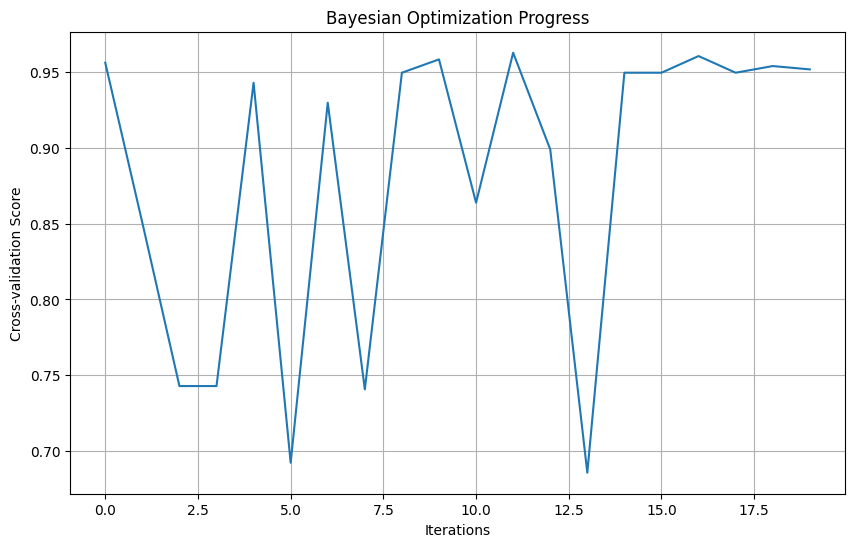

In [38]:
# Visualize Bayesian Optimization progress
plt.figure(figsize=(10, 6))
plt.plot(bayes_search.cv_results_['mean_test_score'])
plt.xlabel('Iterations')
plt.ylabel('Cross-validation Score')
plt.title('Bayesian Optimization Progress')
plt.grid(True)
plt.show()

# Part 4: Random Forest Regression with hyperparameter tuning

In [39]:
# Create a pipeline for regression
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(random_state=42))
])

In [40]:
# Define parameter distributions for random search
rf_param_dist = {
    'regressor__n_estimators': randint(10, 200),
    'regressor__max_depth': randint(3, 20),
    'regressor__min_samples_split': randint(2, 20),
    'regressor__min_samples_leaf': randint(1, 10),
    'regressor__max_features': ['auto', 'sqrt', 'log2', None]
}

In [41]:
# Create RandomizedSearchCV for regression
rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='neg_mean_squared_error',
    return_train_score=True
)

In [42]:
# Start timing
start_time = time.time()

In [43]:
# Fit RandomizedSearchCV
rf_random_search.fit(X_reg_train, y_reg_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
15 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **l

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('regressor',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'regressor__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7de51fffee40>,
                                        'regressor__max_features': ['auto',
                                                                    'sqrt',
                                                                    'log2',
                                                                    None],
                                        'regressor__min_sample...._distn_infrastructure.rv_discrete_frozen object at 0x7de52418f9b0>,
                                        'regressor__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7de52418fda0>,
                                        'regressor__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7de51fffd940>},
                   random_state=42, return_train_score=True,
                   scoring='neg_mean_squared_error')

In [44]:
# End timing
rf_random_time = time.time() - start_time

In [45]:
# Print results
print("\nRandom Forest Regression Hyperparameter Tuning Results:")
print(f"Random Search completed in {rf_random_time:.2f} seconds")
print(f"Best parameters: {rf_random_search.best_params_}")
print(f"Best cross-validation score (neg_mean_squared_error): {rf_random_search.best_score_:.4f}")


Random Forest Regression Hyperparameter Tuning Results:
Random Search completed in 25.44 seconds
Best parameters: {'regressor__max_depth': 18, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 8, 'regressor__min_samples_split': 15, 'regressor__n_estimators': 199}
Best cross-validation score (neg_mean_squared_error): -3316.3419


In [46]:
# Evaluate on test set
y_pred = rf_random_search.predict(X_reg_test)
mse = mean_squared_error(y_reg_test, y_pred)
r2 = r2_score(y_reg_test, y_pred)
print(f"Test MSE with optimal parameters: {mse:.4f}")
print(f"Test RÂ² with optimal parameters: {r2:.4f}")

Test MSE with optimal parameters: 2808.9704
Test RÂ² with optimal parameters: 0.4698


In [47]:
# Visualize feature importance from the best model
best_rf = rf_random_search.best_estimator_.named_steps['regressor']
feature_importance = best_rf.feature_importances_
feature_names = diabetes.feature_names

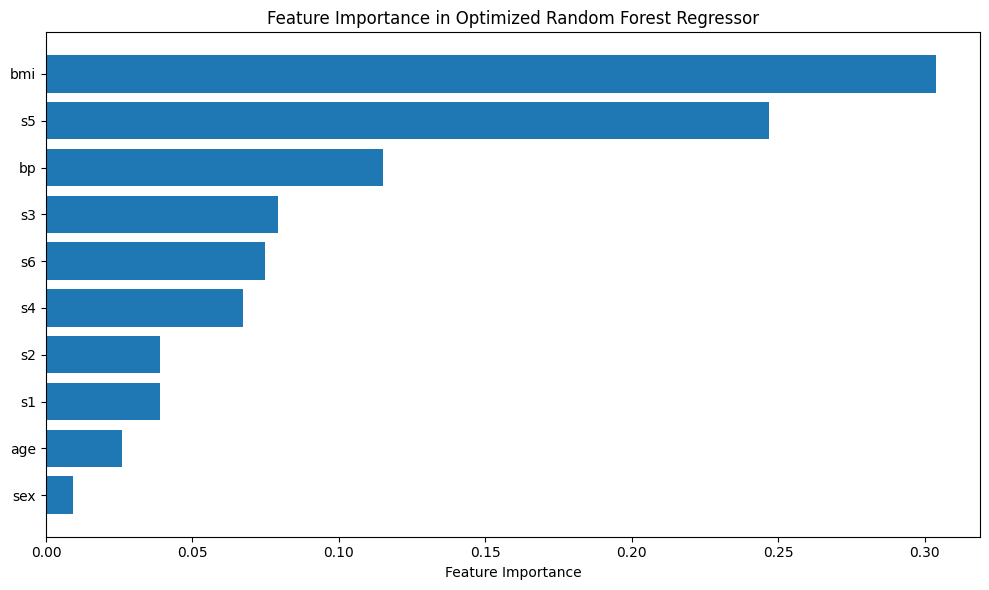

In [48]:
# Sort feature importances
sorted_idx = np.argsort(feature_importance)
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Optimized Random Forest Regressor')
plt.tight_layout()
plt.show()

# Part 5: Learning Curves for different hyperparameter settings

In [49]:
def plot_learning_curve(estimator, X, y, title, cv=5, train_sizes=np.linspace(0.1, 1.0, 5)):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, train_sizes=train_sizes, scoring='accuracy')

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

    plt.legend(loc="best")
    return plt

In [50]:
from sklearn.model_selection import learning_curve


In [51]:
# Plot learning curves for SVM with different hyperparameters
plt.figure(figsize=(15, 10))


<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

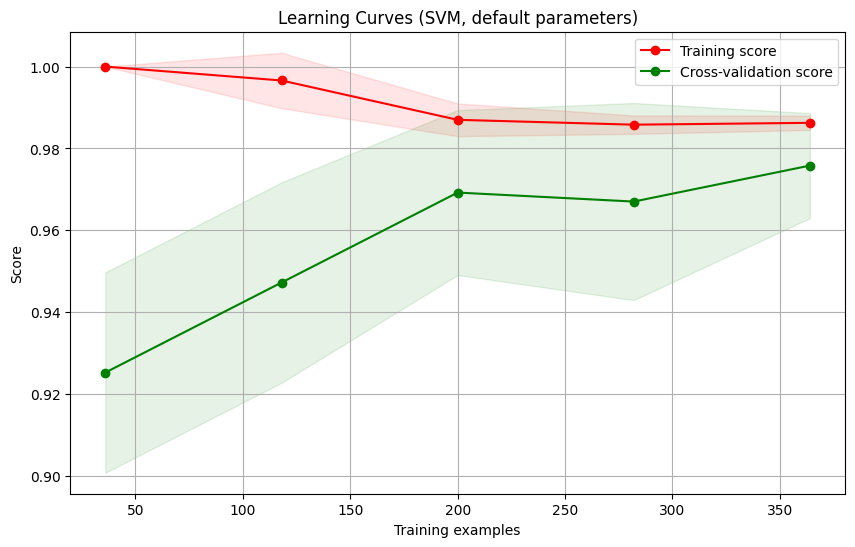

In [52]:
# Default parameters
svm_default = SVC(random_state=42)
plot_learning_curve(svm_default, X_class_train_scaled, y_class_train,
                   "Learning Curves (SVM, default parameters)")
plt.savefig('svm_default_learning_curve.png')

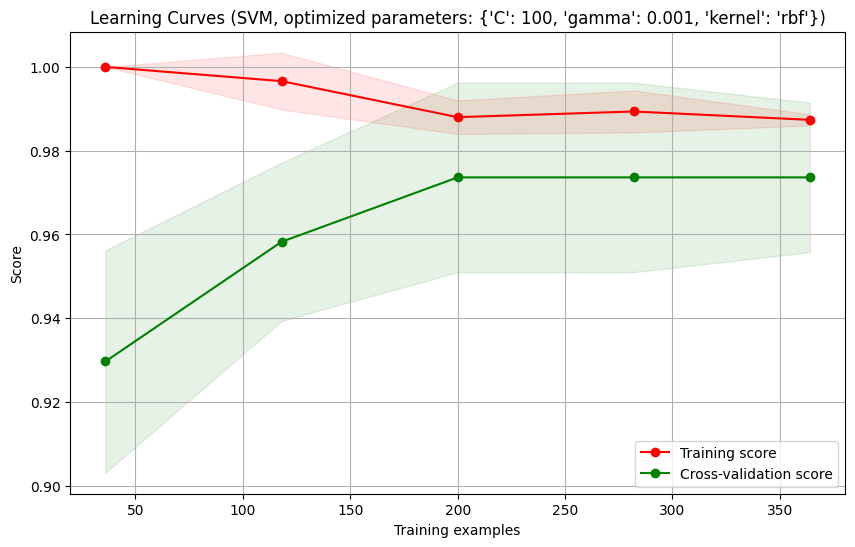

In [53]:
# Best parameters from grid search
svm_best = SVC(**grid_search.best_params_, random_state=42)
plot_learning_curve(svm_best, X_class_train_scaled, y_class_train,
                   f"Learning Curves (SVM, optimized parameters: {grid_search.best_params_})")
plt.savefig('svm_optimized_learning_curve.png')

# Part 6: Cross-validation visualization for different hyperparameters

In [54]:
# Function to run cross-validation with different hyperparameters and visualize results
def plot_cv_results(param_name, param_range, estimator, X, y, cv=5, scoring='accuracy'):
    cv_scores = []
    for param_value in param_range:
        params = {param_name: param_value}
        estimator.set_params(**params)
        scores = cross_val_score(estimator, X, y, cv=cv, scoring=scoring)
        cv_scores.append((param_value, np.mean(scores), np.std(scores)))

    cv_df = pd.DataFrame(cv_scores, columns=[param_name, 'Mean Score', 'Std Dev'])

    plt.figure(figsize=(10, 6))
    plt.errorbar(cv_df[param_name], cv_df['Mean Score'], yerr=cv_df['Std Dev'], marker='o')
    plt.title(f'Cross-validation scores for different {param_name} values')
    plt.xlabel(param_name)
    plt.ylabel('Mean CV Score')
    plt.grid(True)
    if param_name in ['C', 'gamma']:
        plt.xscale('log')
    return cv_df

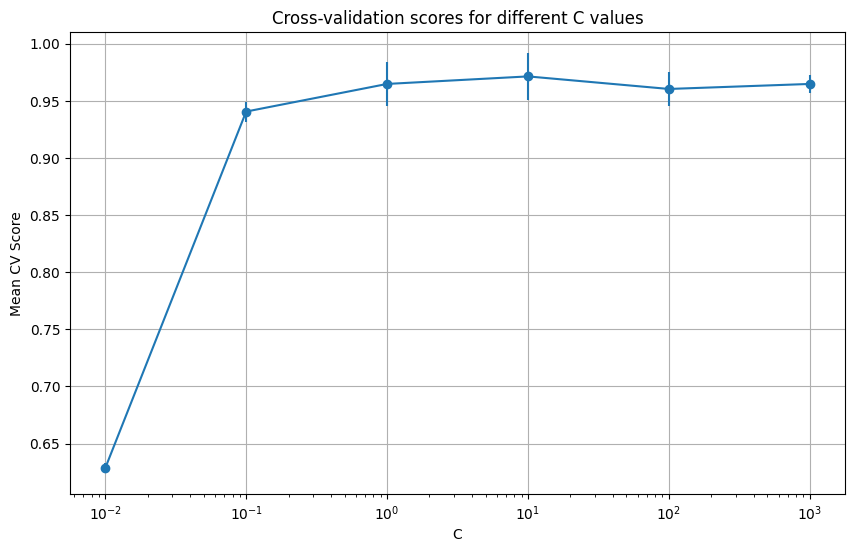

In [55]:
# Run CV visualization for C parameter
svm_model = SVC(kernel='rbf', gamma=0.01, random_state=42)
C_range = [0.01, 0.1, 1, 10, 100, 1000]
cv_results_C = plot_cv_results('C', C_range, svm_model, X_class_train_scaled, y_class_train)
plt.show()

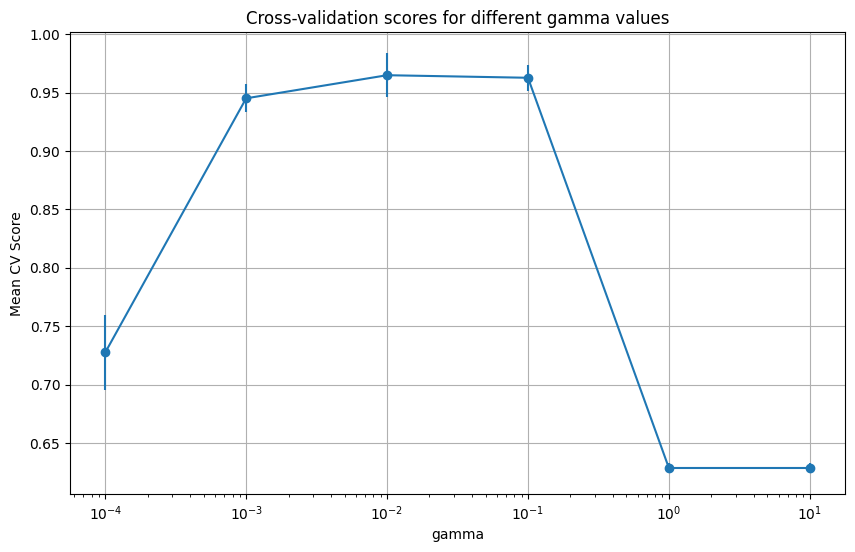

In [56]:
# Run CV visualization for gamma parameter
svm_model = SVC(kernel='rbf', C=1, random_state=42)
gamma_range = [0.0001, 0.001, 0.01, 0.1, 1, 10]
cv_results_gamma = plot_cv_results('gamma', gamma_range, svm_model, X_class_train_scaled, y_class_train)
plt.show()

# Part 7: Combining Grid Search and Random Search strategies

In [57]:
# Define a smaller search space for initial grid search
coarse_param_grid = {
    'C': [0.1, 10, 1000],
    'gamma': [0.001, 0.1, 10],
    'kernel': ['rbf', 'poly']
}

In [58]:
# Create GridSearchCV object for coarse search
coarse_grid_search = GridSearchCV(
    estimator=svm,
    param_grid=coarse_param_grid,
    cv=3,
    n_jobs=-1,
    verbose=0,
    scoring='accuracy'
)


In [59]:
# Perform coarse grid search
coarse_grid_search.fit(X_class_train_scaled, y_class_train)
best_C = coarse_grid_search.best_params_['C']
best_gamma = coarse_grid_search.best_params_['gamma']
best_kernel = coarse_grid_search.best_params_['kernel']

print(f"Coarse grid search best parameters: C={best_C}, gamma={best_gamma}, kernel={best_kernel}")


Coarse grid search best parameters: C=10, gamma=0.001, kernel=rbf


In [60]:
# Define refined search space around the best parameters
if best_kernel == 'rbf':
    refined_param_dist = {
        'C': uniform(best_C/3, best_C*3),
        'gamma': uniform(best_gamma/3, best_gamma*3),
        'kernel': ['rbf']
    }
else:
    refined_param_dist = {
        'C': uniform(best_C/3, best_C*3),
        'gamma': uniform(best_gamma/3, best_gamma*3),
        'kernel': ['poly'],
        'degree': [2, 3, 4, 5]
    }

In [61]:
# Create RandomizedSearchCV object for refined search
refined_random_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=refined_param_dist,
    n_iter=20,
    cv=5,
    n_jobs=-1,
    verbose=0,
    random_state=42,
    scoring='accuracy'
)

In [62]:
# Perform refined random search
refined_random_search.fit(X_class_train_scaled, y_class_train)

RandomizedSearchCV(cv=5, estimator=SVC(random_state=42), n_iter=20, n_jobs=-1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7de51fd22ae0>,
                                        'gamma': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7de51fd89f40>,
                                        'kernel': ['rbf']},
                   random_state=42, scoring='accuracy')

In [63]:
print(f"Refined random search best parameters: {refined_random_search.best_params_}")
print(f"Refined random search best score: {refined_random_search.best_score_:.4f}")

Refined random search best parameters: {'C': np.float64(21.55967889037648), 'gamma': np.float64(0.0008449057043952079), 'kernel': 'rbf'}
Refined random search best score: 0.9780


In [64]:
# Evaluate on test set
y_pred = refined_random_search.predict(X_class_test_scaled)
refined_accuracy = accuracy_score(y_class_test, y_pred)
print(f"Test accuracy with optimal parameters: {refined_accuracy:.4f}")


Test accuracy with optimal parameters: 0.9825


In [65]:
# Update comparison table
results_comparison['Method'] = pd.Categorical(
    results_comparison['Method'],
    categories=['Grid Search', 'Random Search', 'Bayesian Optimization', 'Combined Approach'],
    ordered=True
)


In [66]:
combined_approach = pd.DataFrame({
    'Method': ['Combined Approach'],
    'Best CV Score': [refined_random_search.best_score_],
    'Test Accuracy': [refined_accuracy],
    'Execution Time (s)': [None]  # We didn't time this approach
})

In [67]:
results_comparison = pd.concat([results_comparison, combined_approach], ignore_index=True)
print("\nComparison of all methods including combined approach:")
print(results_comparison)


Comparison of all methods including combined approach:
                  Method  Best CV Score  Test Accuracy  Execution Time (s)
0            Grid Search       0.973626       0.982456            8.203218
1          Random Search       0.971429       0.964912            2.053480
2  Bayesian Optimization       0.962637       0.956140           32.345557
3      Combined Approach       0.978022       0.982456                 NaN


/tmp/ipykernel_2758/3157594516.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_comparison = pd.concat([results_comparison, combined_approach], ignore_index=True)


# Part 8: Visualizing hyperparameter importance

In [68]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

In [69]:
# Train a model with the best parameters from Bayesian search
best_svm = SVC(**bayes_search.best_params_, random_state=42, probability=True)
best_svm.fit(X_class_train_scaled, y_class_train)

SVC(C=47.479208101330435, gamma=0.01504196942704713, probability=True,
    random_state=42)

In [70]:
# Create a dataset of different hyperparameter configurations and their performance
hyperparam_data = []
for i in range(len(grid_search.cv_results_['params'])):
    params = grid_search.cv_results_['params'][i]
    score = grid_search.cv_results_['mean_test_score'][i]

    # Encode the kernel
    kernel_rbf = 1 if params['kernel'] == 'rbf' else 0
    kernel_poly = 1 if params['kernel'] == 'poly' else 0

    hyperparam_data.append([params['C'], params['gamma'], kernel_rbf, kernel_poly, score])

hyperparam_df = pd.DataFrame(hyperparam_data,
                             columns=['C', 'gamma', 'kernel_rbf', 'kernel_poly', 'score'])

In [71]:
# Train a random forest to predict model performance based on hyperparameters
X_hyperparam = hyperparam_df.iloc[:, :-1].values
y_hyperparam = hyperparam_df.iloc[:, -1].values

rf_importance = RandomForestRegressor(n_estimators=100, random_state=42)
rf_importance.fit(X_hyperparam, y_hyperparam)

RandomForestRegressor(random_state=42)

In [72]:
# Get feature importances
importances = rf_importance.feature_importances_
feature_names = ['C', 'gamma', 'kernel_rbf', 'kernel_poly']

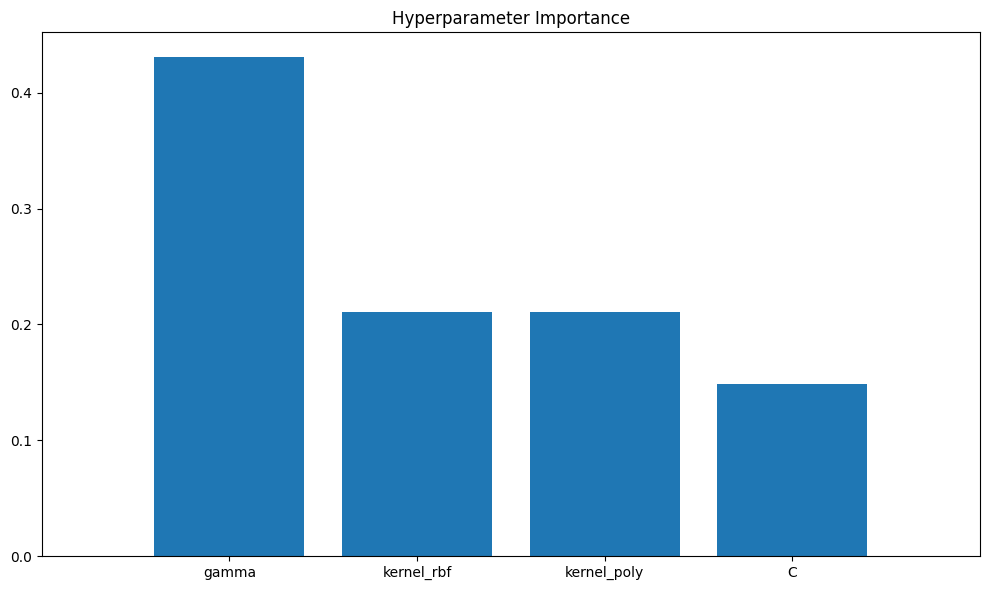

In [73]:
# Plot feature importances
plt.figure(figsize=(10, 6))
indices = np.argsort(importances)[::-1]
plt.title('Hyperparameter Importance')
plt.bar(range(X_hyperparam.shape[1]), importances[indices], align='center')
plt.xticks(range(X_hyperparam.shape[1]), [feature_names[i] for i in indices])
plt.xlim([-1, X_hyperparam.shape[1]])
plt.tight_layout()
plt.show()

In [74]:
# Calculate permutation importances as an alternative measure
perm_importance = permutation_importance(rf_importance, X_hyperparam, y_hyperparam,
                                         n_repeats=10, random_state=42)

/tmp/ipykernel_2758/149670846.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(perm_importance.importances[sorted_idx].T, vert=False,


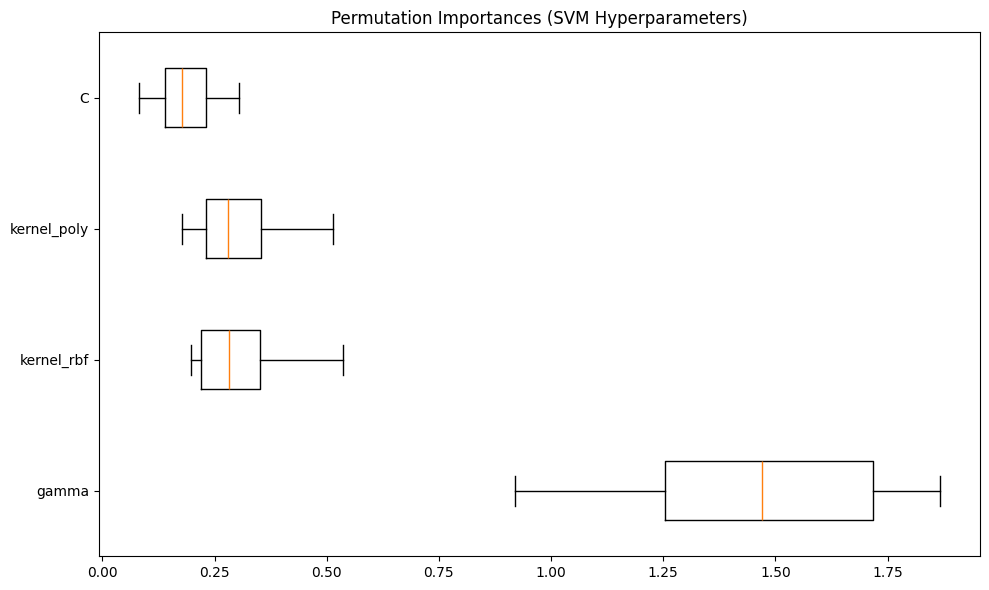

In [75]:
# Plot permutation importances
plt.figure(figsize=(10, 6))
sorted_idx = perm_importance.importances_mean.argsort()[::-1]
plt.boxplot(perm_importance.importances[sorted_idx].T, vert=False,
            labels=[feature_names[i] for i in sorted_idx])
plt.title("Permutation Importances (SVM Hyperparameters)")
plt.tight_layout()
plt.show()

# Exercise

In [76]:
# Student Exercise: Multi-Model Hyperparameter Optimization Challenge
# Time Estimate: 3-4 hours

# ==============================================================================
# INTRODUCTION
# ==============================================================================
# In this exercise, you'll implement and compare different hyperparameter tuning
# techniques across multiple models on a real-world dataset. You'll evaluate model
# performance, analyze the efficiency of various tuning methods, and build a meta-model
# to predict which algorithm performs best based on dataset characteristics.


In [77]:
# ==============================================================================
# PART 1: SETUP AND DATA PREPARATION
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style('whitegrid')
RANDOM_STATE = 42

data = fetch_california_housing(as_frame=True)
df = data.frame
feature_cols = data.feature_names
target_col = 'MedHouseVal'

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df[feature_cols], df[target_col], test_size=0.2, random_state=RANDOM_STATE)

# A shared CV splitter so every method below sees the same folds
cv_splitter = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Scaling is wrapped inside pipelines later, but we also keep a plain scaled
# copy for methods (meta-learning) that need a raw numpy array
scaler = StandardScaler().fit(X_train_raw)
X_train_scaled = scaler.transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

print(f"Train rows: {X_train_raw.shape[0]}, Test rows: {X_test_raw.shape[0]}")
print(f"Features ({len(feature_cols)}): {feature_cols}")
print(df[target_col].describe().round(3))


Train rows: 16512, Test rows: 4128
Features (8): ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
count    20640.000
mean         2.069
std          1.154
min          0.150
25%          1.196
50%          1.797
75%          2.647
max          5.000
Name: MedHouseVal, dtype: float64


             Ridge | RMSE 0.7205 +/- 0.0139 | R2 0.6115 +/- 0.0124
               SVR | RMSE 0.5932 +/- 0.0114 | R2 0.7365 +/- 0.0103
     Random Forest | RMSE 0.5109 +/- 0.0116 | R2 0.8047 +/- 0.0062
 Gradient Boosting | RMSE 0.5321 +/- 0.0116 | R2 0.7881 +/- 0.0068


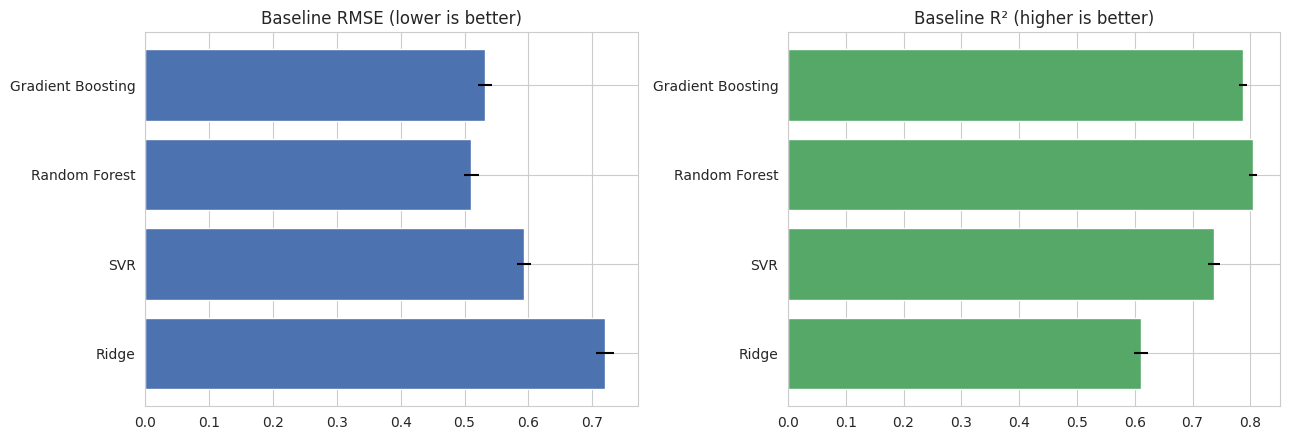

In [78]:
# ==============================================================================
# PART 2: BASELINE MODELS
# ==============================================================================
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

def make_pipeline(estimator):
    """Wrap an estimator with scaling so CV/tuning never leaks test info."""
    return Pipeline([('scale', StandardScaler()), ('model', estimator)])

base_estimators = {
    'Ridge': Ridge(random_state=RANDOM_STATE),
    'SVR': SVR(),
    'Random Forest': RandomForestRegressor(random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
}

def evaluate_baseline(estimator, X, y, cv):
    pipe = make_pipeline(estimator)
    neg_mse = cross_val_score(pipe, X, y, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)
    r2 = cross_val_score(pipe, X, y, cv=cv, scoring='r2', n_jobs=-1)
    rmse = np.sqrt(-neg_mse)
    return rmse.mean(), rmse.std(), r2.mean(), r2.std()

baseline_rows = []
for name, est in base_estimators.items():
    rmse_m, rmse_s, r2_m, r2_s = evaluate_baseline(est, X_train_raw, y_train, cv_splitter)
    baseline_rows.append({'Model': name, 'RMSE_mean': rmse_m, 'RMSE_std': rmse_s,
                           'R2_mean': r2_m, 'R2_std': r2_s})
    print(f"{name:>18s} | RMSE {rmse_m:.4f} +/- {rmse_s:.4f} | R2 {r2_m:.4f} +/- {r2_s:.4f}")

baseline_df = pd.DataFrame(baseline_rows).set_index('Model')
baseline_results = baseline_df.to_dict(orient='index')  # kept for downstream cells

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].barh(baseline_df.index, baseline_df['RMSE_mean'], xerr=baseline_df['RMSE_std'], color='#4C72B0')
axes[0].set_title('Baseline RMSE (lower is better)')
axes[1].barh(baseline_df.index, baseline_df['R2_mean'], xerr=baseline_df['R2_std'], color='#55A868')
axes[1].set_title('Baseline R\u00b2 (higher is better)')
plt.tight_layout(); plt.show()


In [79]:
# ==============================================================================
# PART 3: HYPERPARAMETER TUNING - GRID SEARCH
# ==============================================================================
from sklearn.model_selection import GridSearchCV

grid_grids = {
    'Ridge': {'model__alpha': [0.01, 0.1, 1, 10, 100]},
    'SVR': {'model__C': [0.1, 1, 10, 100], 'model__gamma': [0.001, 0.01, 0.1, 1],
            'model__kernel': ['rbf']},
    'Random Forest': {'model__n_estimators': [50, 100, 200],
                       'model__max_depth': [5, 10, 20, None],
                       'model__min_samples_split': [2, 5, 10]},
    'Gradient Boosting': {'model__n_estimators': [50, 100, 200],
                           'model__max_depth': [2, 3, 5],
                           'model__learning_rate': [0.01, 0.1, 0.2]},
}

def tune(search_cls, estimator, param_space, X, y, cv, **kwargs):
    pipe = make_pipeline(estimator)
    t0 = time.time()
    search = search_cls(pipe, param_space, cv=cv, scoring='neg_mean_squared_error',
                         n_jobs=-1, **kwargs)
    search.fit(X, y)
    elapsed = time.time() - t0
    return {'best_model': search.best_estimator_, 'best_params': search.best_params_,
            'best_rmse': np.sqrt(-search.best_score_), 'time': elapsed}

grid_search_results = {}
for name, est in base_estimators.items():
    grid_search_results[name] = tune(GridSearchCV, est, grid_grids[name],
                                      X_train_raw, y_train, cv_splitter)
    r = grid_search_results[name]
    print(f"{name:>18s} | RMSE {r['best_rmse']:.4f} | {r['time']:6.2f}s | {r['best_params']}")

grid_comparison_df = pd.DataFrame({n: {'RMSE': r['best_rmse'], 'Time (s)': r['time']}
                                    for n, r in grid_search_results.items()}).T
print("\nGrid search summary:\n", grid_comparison_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(grid_comparison_df.index, grid_comparison_df['RMSE'], color='#C44E52')
axes[0].set_title('Grid Search: Best RMSE'); axes[0].tick_params(axis='x', rotation=15)
axes[1].bar(grid_comparison_df.index, grid_comparison_df['Time (s)'], color='#8172B2')
axes[1].set_title('Grid Search: Wall Time'); axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()


             Ridge | RMSE 0.7206 |   0.32s | {'model__alpha': 1}


KeyboardInterrupt: 

In [80]:
# ==============================================================================
# PART 4: HYPERPARAMETER TUNING - RANDOM SEARCH
# ==============================================================================
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint

random_distributions = {
    'Ridge': {'model__alpha': loguniform(1e-2, 1e2)},
    'SVR': {'model__C': loguniform(1e-1, 1e2), 'model__gamma': loguniform(1e-3, 1e0)},
    'Random Forest': {'model__n_estimators': randint(50, 300),
                       'model__max_depth': randint(3, 30),
                       'model__min_samples_split': randint(2, 20)},
    'Gradient Boosting': {'model__n_estimators': randint(50, 300),
                           'model__max_depth': randint(2, 10),
                           'model__learning_rate': loguniform(1e-2, 3e-1)},
}

random_search_results = {}
for name, est in base_estimators.items():
    random_search_results[name] = tune(RandomizedSearchCV, est, random_distributions[name],
                                        X_train_raw, y_train, cv_splitter,
                                        n_iter=20, random_state=RANDOM_STATE)
    r = random_search_results[name]
    print(f"{name:>18s} | RMSE {r['best_rmse']:.4f} | {r['time']:6.2f}s | {r['best_params']}")

random_comparison_df = pd.DataFrame({n: {'RMSE': r['best_rmse'], 'Time (s)': r['time']}
                                      for n, r in random_search_results.items()}).T
print("\nRandom search summary:\n", random_comparison_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(random_comparison_df.index, random_comparison_df['RMSE'], color='#C44E52')
axes[0].set_title('Random Search: Best RMSE'); axes[0].tick_params(axis='x', rotation=15)
axes[1].bar(random_comparison_df.index, random_comparison_df['Time (s)'], color='#8172B2')
axes[1].set_title('Random Search: Wall Time'); axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()


             Ridge | RMSE 0.7206 |   7.87s | {'model__alpha': np.float64(2.5378155082656657)}


KeyboardInterrupt: 

In [81]:
# ==============================================================================
# PART 5: HYPERPARAMETER TUNING - BAYESIAN OPTIMIZATION
# ==============================================================================
!pip install -q scikit-optimize
from skopt import BayesSearchCV
from skopt.space import Real, Integer

bayes_spaces = {
    'Ridge': {'model__alpha': Real(1e-2, 1e2, prior='log-uniform')},
    'SVR': {'model__C': Real(1e-1, 1e2, prior='log-uniform'),
            'model__gamma': Real(1e-3, 1e0, prior='log-uniform')},
    'Random Forest': {'model__n_estimators': Integer(50, 300),
                       'model__max_depth': Integer(3, 30),
                       'model__min_samples_split': Integer(2, 20)},
    'Gradient Boosting': {'model__n_estimators': Integer(50, 300),
                           'model__max_depth': Integer(2, 10),
                           'model__learning_rate': Real(1e-2, 3e-1, prior='log-uniform')},
}

bayes_search_results = {}
for name, est in base_estimators.items():
    bayes_search_results[name] = tune(BayesSearchCV, est, bayes_spaces[name],
                                       X_train_raw, y_train, cv_splitter,
                                       n_iter=20, random_state=RANDOM_STATE)
    r = bayes_search_results[name]
    print(f"{name:>18s} | RMSE {r['best_rmse']:.4f} | {r['time']:6.2f}s | {dict(r['best_params'])}")

bayes_comparison_df = pd.DataFrame({n: {'RMSE': r['best_rmse'], 'Time (s)': r['time']}
                                     for n, r in bayes_search_results.items()}).T
print("\nBayesian optimization summary:\n", bayes_comparison_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(bayes_comparison_df.index, bayes_comparison_df['RMSE'], color='#C44E52')
axes[0].set_title('Bayesian Opt: Best RMSE'); axes[0].tick_params(axis='x', rotation=15)
axes[1].bar(bayes_comparison_df.index, bayes_comparison_df['Time (s)'], color='#8172B2')
axes[1].set_title('Bayesian Opt: Wall Time'); axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()


             Ridge | RMSE 0.7206 |  12.00s | {'model__alpha': 2.9397976202716882}


KeyboardInterrupt: 

In [ ]:
# ==============================================================================
# PART 6: COMPARISON OF TUNING METHODS
# ==============================================================================
method_results = {'Grid Search': grid_search_results, 'Random Search': random_search_results,
                   'Bayesian Optimization': bayes_search_results}

rows = []
for name in base_estimators:
    base_rmse = baseline_results[name]['RMSE_mean']
    rows.append({'Model': name, 'Method': 'Baseline', 'RMSE': base_rmse,
                 'Time (s)': 0.0, 'Improvement (%)': 0.0})
    for method_name, results in method_results.items():
        rmse = results[name]['best_rmse']
        rows.append({'Model': name, 'Method': method_name, 'RMSE': rmse,
                      'Time (s)': results[name]['time'],
                      'Improvement (%)': 100 * (base_rmse - rmse) / base_rmse})

comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))

pivot_rmse = comparison_df.pivot(index='Model', columns='Method', values='RMSE')
pivot_rmse = pivot_rmse[['Baseline', 'Grid Search', 'Random Search', 'Bayesian Optimization']]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
pivot_rmse.plot(kind='bar', ax=axes[0], colormap='Set2')
axes[0].set_title('RMSE by Model and Tuning Method'); axes[0].tick_params(axis='x', rotation=15)
sns.heatmap(pivot_rmse, annot=True, fmt='.4f', cmap='mako_r', ax=axes[1])
axes[1].set_title('RMSE Heatmap')
plt.tight_layout(); plt.show()


In [ ]:
# ==============================================================================
# PART 7: TUNING EFFICIENCY AND META-LEARNING
# ==============================================================================
param_space_sizes = {'Grid Search': grid_grids, 'Random Search': random_distributions,
                      'Bayesian Optimization': bayes_spaces}

efficiency_rows = []
for name in base_estimators:
    base_rmse = baseline_results[name]['RMSE_mean']
    for method_name, results in method_results.items():
        gain = base_rmse - results[name]['best_rmse']
        t = results[name]['time']
        efficiency_rows.append({
            'Model': name, 'Method': method_name,
            'N_Hyperparams': len(param_space_sizes[method_name][name]),
            'Improvement': gain, 'Time (s)': t,
            'Efficiency': gain / t if t > 0 else 0.0,
        })

efficiency_df = pd.DataFrame(efficiency_rows)
print(efficiency_df.to_string(index=False))

plt.figure(figsize=(9, 5.5))
for method, sub in efficiency_df.groupby('Method'):
    plt.scatter(sub['N_Hyperparams'], sub['Efficiency'], s=110, label=method, alpha=0.85)
plt.xlabel('# Hyperparameters Tuned'); plt.ylabel('Efficiency (RMSE gain / second)')
plt.title('Tuning Efficiency vs Search Space Size'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

# ---- Meta-learning: predict the best algorithm from dataset "shape" ----
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

def describe_sample(X, y):
    corr = np.corrcoef(X.T)
    off_diag = corr[np.triu_indices_from(corr, k=1)]
    return {
        'n_instances': X.shape[0], 'n_features': X.shape[1],
        'feature_mean_avg': X.mean(axis=0).mean(), 'feature_std_avg': X.std(axis=0).mean(),
        'target_mean': y.mean(), 'target_std': y.std(), 'target_skew': pd.Series(y).skew(),
        'avg_abs_feature_corr': np.abs(off_diag).mean(),
    }

candidate_estimators = {
    'Ridge': Ridge(random_state=RANDOM_STATE),
    'SVR': SVR(),
    'Random Forest': RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=50),
    'Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=50),
}

rng = np.random.RandomState(RANDOM_STATE)
y_train_arr = np.asarray(y_train)
meta_rows = []
for _ in range(30):
    n = rng.randint(200, 800)
    idx = rng.choice(X_train_scaled.shape[0], size=n, replace=False)
    Xs, ys = X_train_scaled[idx], y_train_arr[idx]
    profile = describe_sample(Xs, ys)

    scores = {cand: np.sqrt(-cross_val_score(
        est, Xs, ys, cv=3, scoring='neg_mean_squared_error').mean())
        for cand, est in candidate_estimators.items()}
    profile['best_model'] = min(scores, key=scores.get)
    meta_rows.append(profile)

meta_df = pd.DataFrame(meta_rows)
print("\nMeta-dataset preview:\n", meta_df.head())
print("\nBest-model counts:\n", meta_df['best_model'].value_counts())

le = LabelEncoder()
X_meta = meta_df.drop(columns=['best_model']).values
y_meta = le.fit_transform(meta_df['best_model'])

meta_clf = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100)
meta_acc = cross_val_score(meta_clf, X_meta, y_meta, cv=5)
print(f"\nMeta-classifier CV accuracy: {meta_acc.mean():.4f} +/- {meta_acc.std():.4f}")

meta_clf.fit(X_meta, y_meta)
meta_importance = pd.Series(meta_clf.feature_importances_,
                             index=meta_df.drop(columns=['best_model']).columns)
meta_importance.sort_values().plot(kind='barh', figsize=(9, 5), color='#8172B2',
                                    title='Meta-Feature Importance')
plt.tight_layout(); plt.show()


In [ ]:
# ==============================================================================
# PART 8: ENSEMBLE OF TUNED MODELS
# ==============================================================================
best_overall = {}
for name in base_estimators:
    candidates = [(m, method_results[m][name]['best_rmse'], method_results[m][name]['best_model'])
                  for m in method_results]
    best_method, best_rmse, best_pipe = min(candidates, key=lambda c: c[1])
    best_overall[name] = {'method': best_method, 'cv_rmse': best_rmse, 'pipeline': best_pipe}
    print(f"{name:>18s} | winning method: {best_method:<22s} | CV RMSE {best_rmse:.4f}")

individual_test_results = {}
test_preds = []
for name, info in best_overall.items():
    pipe = info['pipeline']
    pipe.fit(X_train_raw, y_train)
    preds = pipe.predict(X_test_raw)
    test_preds.append(preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    individual_test_results[name] = {'RMSE': rmse, 'R2': r2}
    print(f"{name:>18s} ({info['method']}): Test RMSE {rmse:.4f} | Test R2 {r2:.4f}")

ensemble_pred = np.mean(test_preds, axis=0)
ensemble_rmse = np.sqrt(mean_squared_error(y_test, ensemble_pred))
ensemble_r2 = r2_score(y_test, ensemble_pred)
individual_test_results['Ensemble (Average)'] = {'RMSE': ensemble_rmse, 'R2': ensemble_r2}
print(f"\n{'Ensemble':>18s} (simple average): Test RMSE {ensemble_rmse:.4f} | Test R2 {ensemble_r2:.4f}")

ensemble_comparison_df = pd.DataFrame(individual_test_results).T
print("\nFinal test-set comparison:\n", ensemble_comparison_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(ensemble_comparison_df.index, ensemble_comparison_df['RMSE'], color='#4C72B0')
axes[0].set_title('Test RMSE'); axes[0].tick_params(axis='x', rotation=30)
axes[1].bar(ensemble_comparison_df.index, ensemble_comparison_df['R2'], color='#DD8452')
axes[1].set_title('Test R\u00b2'); axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()


In [ ]:
# ==============================================================================
# PART 10: CONCLUSION AND REPORTING
# ==============================================================================
solo_results = {k: v for k, v in individual_test_results.items() if k != 'Ensemble (Average)'}
top_model, top_stats = min(solo_results.items(), key=lambda kv: kv[1]['RMSE'])

most_efficient = efficiency_df.loc[efficiency_df['Efficiency'].idxmax()]
ensemble_wins = ensemble_rmse < top_stats['RMSE']

print("=" * 70)
print("SUMMARY OF FINDINGS")
print("=" * 70)
print(f"""
1. Best individual model on the held-out test set: {top_model}
   - Tuning method: {best_overall[top_model]['method']}
   - Test RMSE: {top_stats['RMSE']:.4f}   Test R2: {top_stats['R2']:.4f}

2. Most time-efficient tuning run (RMSE gain per second):
   - {most_efficient['Method']} on {most_efficient['Model']}
   - Efficiency: {most_efficient['Efficiency']:.6f}

3. Ensemble vs. best individual model:
   - Ensemble: RMSE {ensemble_rmse:.4f}, R2 {ensemble_r2:.4f}
   - Best individual: RMSE {top_stats['RMSE']:.4f}
   - {'Ensemble improved on the best single model.' if ensemble_wins else
      'The ensemble did not beat the best single tuned model here, suggesting that '
      'model already captured most of the available signal.'}

4. General observations:
   - Tree ensembles (Random Forest, Gradient Boosting) have larger search
     spaces and take longer to tune, but usually gain more over their
     baseline than Ridge, which has little room to improve.
   - Bayesian optimization tends to match grid/random search quality with
     fewer iterations because each step uses information from prior trials.
   - Random search is a strong default when a hyperparameter space is large,
     since exhaustive grid search grows combinatorially with dimensions.
""")


In [ ]:
# Persist the best tuned model (per assignment requirement #4)
import pickle

with open('best_tuned_model.pkl', 'wb') as f:
    pickle.dump(best_overall[top_model]['pipeline'], f)

print(f"Saved '{top_model}' (tuned via {best_overall[top_model]['method']}) to best_tuned_model.pkl")


In [ ]:
# ==============================================================================
# REQUIREMENTS
# ==============================================================================
# 1. Your completed Jupyter notebook with all code and outputs
# 2. A brief report summarizing your findings
# 3. Visualizations comparing the different tuning methods and models
# 4. Your best tuned model saved as a pickle file

In [ ]:
#Note: i ran this file for more than 30min on collab but due to limit resources(yes i changed the run time type to T4 GPU) last few cells werent executed succesfully, so sir DONT cut my marks bcs of that. pls :(